In [2]:
from SymbolicDSGE import ModelParser, DSGESolver
from SymbolicDSGE.utils import FRED
from SymbolicDSGE.utils.math_utils import HP_two_sided, annualized_log_percent
from SymbolicDSGE.bayesian import make_prior
from SymbolicDSGE.estimation import MCMCResult

from sympy import Matrix
from warnings import catch_warnings, simplefilter
from typing import cast

import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
model, kalman = ModelParser("../../MODELS/POST82.yaml").get_all()

with catch_warnings():
    # Equations in a sp.Matrix are deprecated, this is only used as a pretty print function
    simplefilter(action="ignore")
    mat = Matrix(model.equations.model)
mat

Matrix([
[                                    Eq(Pi(t), beta*Pi(t + 1) + kappa*(x(t) - z(t)))],
[                           Eq(x(t), -tau_inv*(-Pi(t + 1) + r(t)) + g(t) + x(t + 1))],
[Eq(r(t), e_r + rho_r*r(t - 1*1) + (1 - rho_r)*(psi_pi*Pi(t) + psi_x*(x(t) - z(t))))],
[                                                   Eq(g(t), e_g + rho_g*g(t - 1*1))],
[                                                   Eq(z(t), e_z + rho_z*z(t - 1*1))]])

In [4]:
fred = FRED(
    key_env=None,  # None => look for the ".env" file. If you have a custom env file, provide its path here.
    key_name="FRED_KEY",  # Name of the variable in the env file that contains the FRED API key.
)
df = fred.get_frame(
    series_ids=[
        "GDPC1",  # Real GDP
        "CPIAUCSL",  # Consumer Price Index for All Urban Consumers: All Items
        "FEDFUNDS",  # Effective Federal Funds Rate
    ],
    date_range=(
        "1955-01-01",
        "2007-10-01",
    ),  # Date range for the data ("YYYY-MM-DD" format or a pd.DatetimeIndex object)
)

gdp_q = df["GDPC1"]  # already quarterly in most pulls; verify freq

cpi_q = df["CPIAUCSL"].resample("QS").mean()  # quarterly avg CPI
ffr_q = df["FEDFUNDS"].resample("QS").mean()  # quarterly avg policy rate

idx_range = pd.date_range(start="1984-01-01", end="2007-01-01", freq="QS")


df = pd.DataFrame(
    {
        "GDPC1": gdp_q.reindex(idx_range),
        "CPIAUCSL": cpi_q.reindex(idx_range),
        "FEDFUNDS": ffr_q.reindex(idx_range),
    }
)

df

,GDPC1,CPIAUCSL,FEDFUNDS
1984-01-01,8034.847,102.533333,9.686667
1984-04-01,8173.670,103.500000,10.556667
1984-07-01,8252.465,104.400000,11.390000
1984-10-01,8320.199,105.300000,9.266667
1985-01-01,8400.820,106.266667,8.476667
...,...,...,...
2006-01-01,16353.835,199.466667,4.456667
2006-04-01,16396.151,201.266667,4.906667
2006-07-01,16420.738,203.166667,5.246667
2006-10-01,16561.866,202.333333,5.246667


In [5]:
x_trend = HP_two_sided(np.log(df["GDPC1"]), lamb=1600)[0]  # returns (trend, cycle)
x = (np.log(df["GDPC1"]) - x_trend) * 100  # HP detrended quarterly log output gap


inf_lvl = annualized_log_percent(df["CPIAUCSL"], periods_per_year=4)
rate_lvl = df["FEDFUNDS"]

r_ss = model.calibration.parameters["r_star"]
pi_ss = model.calibration.parameters["pi_star"]

rate = (rate_lvl - (r_ss + pi_ss)) / 4  # gap to steady state
inf = (inf_lvl - pi_ss) / 4  # gap to steady state

df_model_units = pd.DataFrame(
    {
        "r": rate,
        "Pi": inf,
        "x": x,
    }
).dropna()

observed = pd.DataFrame(
    {
        "Infl": inf_lvl[df_model_units.index],
        "Rate": rate_lvl[df_model_units.index],
    }
)
observed.index = df_model_units.index

In [14]:
prior_spec = {
    # (0, 1)
    "beta": make_prior(
        "beta",
        parameters={"a": 200 * 0.971, "b": 200 * 0.029},
        transform="logit",
    ),
    "rho_r": make_prior(
        "beta",
        parameters={"a": 200 * 0.84, "b": 200 * 0.16},
        transform="logit",
    ),
    "rho_g": make_prior(
        "beta",
        parameters={"a": 200 * 0.83, "b": 200 * 0.17},
        transform="logit",
    ),
    "rho_z": make_prior(
        "beta",
        parameters={"a": 200 * 0.85, "b": 200 * 0.15},
        transform="logit",
    ),
    # (0, +inf)
    "psi_pi": make_prior(
        "gamma",
        parameters={"mean": 2.19, "std": 0.5},
        transform="log",
    ),
    "psi_x": make_prior(
        "gamma",
        parameters={"mean": 0.30, "std": 0.1},
        transform="log",
    ),
    "kappa": make_prior(
        "gamma",
        parameters={"mean": 0.58, "std": 0.1},
        transform="log",
    ),
    "tau_inv": make_prior(
        "gamma",
        parameters={"mean": 1.86, "std": 0.5},
        transform="log",
    ),
    # Correlation (-1,1)
    "rho_gz": make_prior(
        "normal",
        parameters={"mean": 0.0, "std": 0.20},
        transform="affine_logit",
        transform_kwargs={
            "low": -1.0,
            "high": 1.0,
        },
    ),
    "meas_rho_ir": make_prior(
        "normal",
        parameters={"mean": 0.0, "std": 0.4},
        transform="affine_logit",
        transform_kwargs={"low": -1.0, "high": 1.0},
    ),
    # Shock std devs (0, +inf)
    "sig_r": make_prior(
        "gamma",
        parameters={"mean": 0.18, "std": 0.1},
        transform="log",
    ),
    "sig_g": make_prior(
        "gamma",
        parameters={"mean": 0.18, "std": 0.1},
        transform="log",
    ),
    "sig_z": make_prior(
        "gamma",
        parameters={"mean": 0.64, "std": 0.1},
        transform="log",
    ),
    "meas_infl": make_prior(
        "normal",
        parameters={"mean": 0.0, "std": 0.4},
        transform="identity",
    ),
    "meas_rate": make_prior(
        "normal",
        parameters={"mean": 0.0, "std": 0.4},
        transform="identity",
    ),
}

solver = DSGESolver(model, kalman)
comp = solver.compile()

res, sol = solver.estimate_and_solve(
    compiled=comp,
    filter_mode="linear",
    y=observed.loc[observed.index >= "1984-01-01", :],
    observables=["Infl", "Rate"],
    priors=prior_spec,
    method="mcmc",
    posterior_point="mean",
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    n_draws=100_000,
    burn_in=10_000,
    thin=1,
)

res = cast(MCMCResult, res)  # type hint for IDEs

MCMC sampling concluded in 71.61 seconds with 1536.00 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


In [7]:
param_names = res.param_names

best_idx = np.argmax(res.logpost_trace)

post_mean = np.mean(res.samples, axis=0)
loglik = np.mean(res.logpost_trace)
accept_rate = res.accept_rate
n_draws = res.n_draws
burn_in = res.burn_in
thin = res.thin

param_to_val = dict(zip(param_names, post_mean))


pd.Series(
    {
        **param_to_val,
        "loglik": loglik,
        "accept_rate": accept_rate,
        "n_draws": n_draws,
        "burn_in": burn_in,
        "thin": thin,
    }
).round(3)

beta                0.969
rho_r               0.774
rho_g               0.825
rho_z               0.889
psi_pi              4.163
psi_x               0.367
kappa               0.366
tau_inv             0.409
rho_gz              0.099
meas_rho_ir         0.023
sig_r               0.032
sig_g               0.062
sig_z               0.678
meas_infl           1.421
meas_rate           0.002
loglik           -267.071
accept_rate         0.165
n_draws        100000.000
burn_in         10000.000
thin                1.000
dtype: float64

In [8]:
res.hpd_intervals(alpha=0.05, n_digits=3)

{'beta': (np.float64(0.943), np.float64(0.99)),
 'rho_r': (np.float64(0.725), np.float64(0.82)),
 'rho_g': (np.float64(0.762), np.float64(0.891)),
 'rho_z': (np.float64(0.854), np.float64(0.924)),
 'psi_pi': (np.float64(3.122), np.float64(5.171)),
 'psi_x': (np.float64(0.159), np.float64(0.611)),
 'kappa': (np.float64(0.218), np.float64(0.512)),
 'tau_inv': (np.float64(0.216), np.float64(0.631)),
 'rho_gz': (np.float64(-0.326), np.float64(0.543)),
 'meas_rho_ir': (np.float64(-0.843), np.float64(0.843)),
 'sig_r': (np.float64(0.01), np.float64(0.057)),
 'sig_g': (np.float64(0.011), np.float64(0.122)),
 'sig_z': (np.float64(0.491), np.float64(0.875)),
 'meas_infl': (np.float64(1.209), np.float64(1.629)),
 'meas_rate': (np.float64(-0.118), np.float64(0.118))}

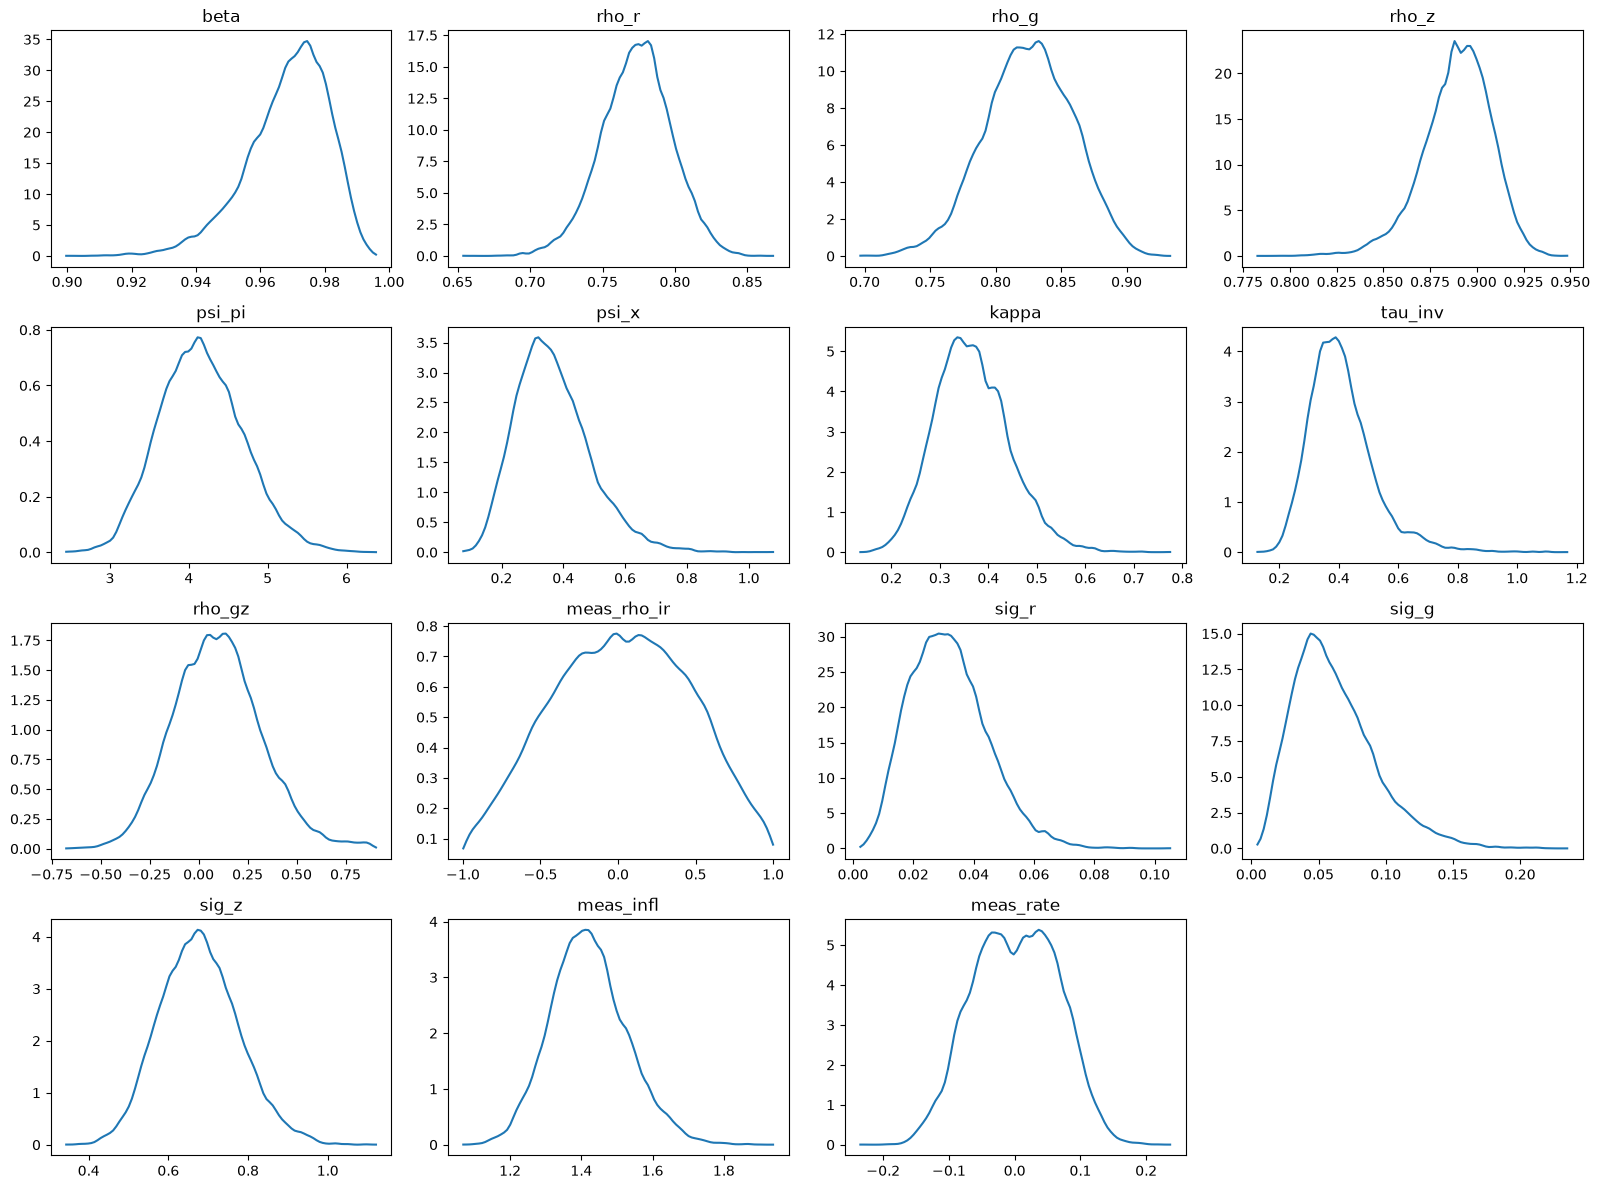

In [10]:
res.posterior_kde_plot(grid_points=100)

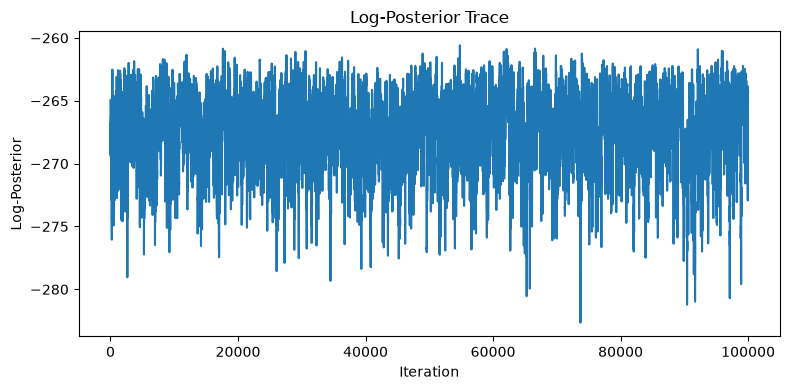

In [11]:
res.logpost_trace_plot()

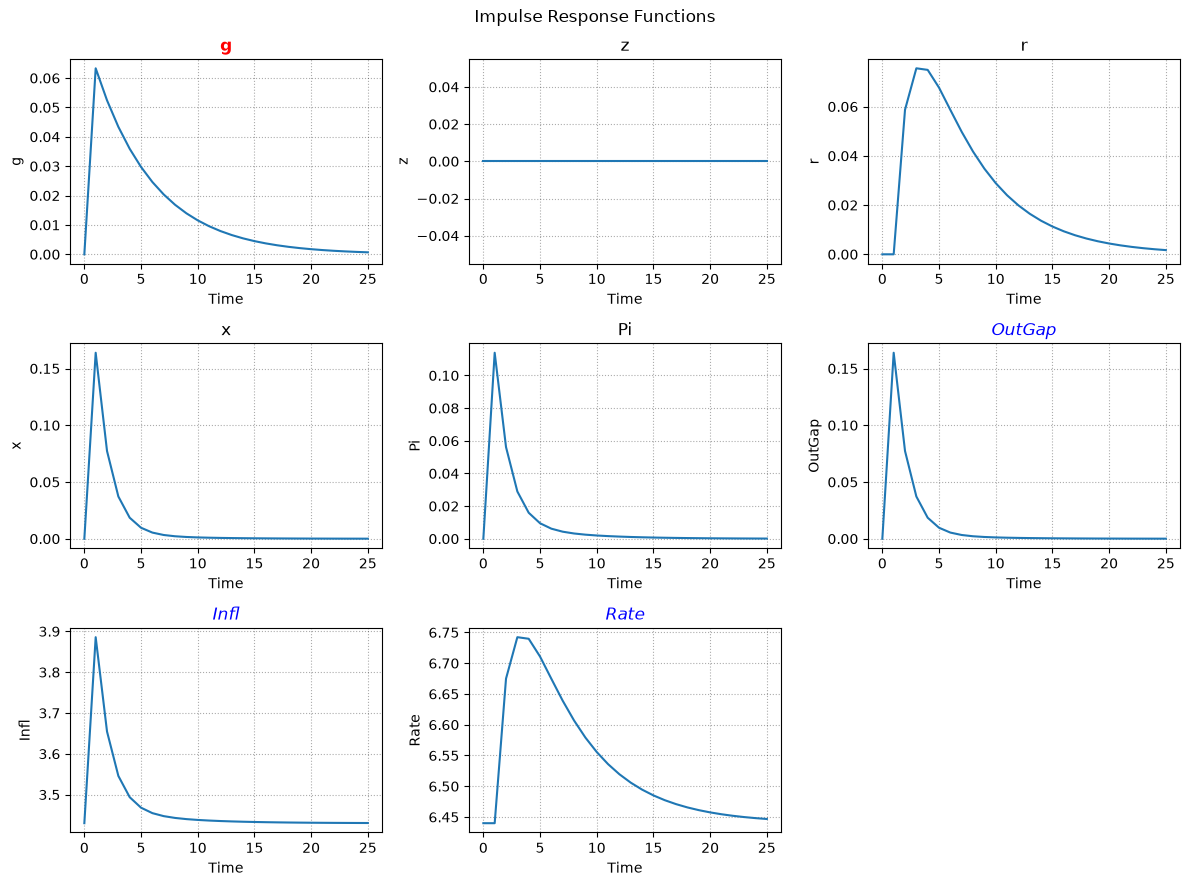

In [9]:
sol.transition_plot(shocks=["g"], T=25, scale=1, observables=True)

In [12]:
kf_0 = sol.kalman(
    observed.loc[observed.index >= "1984-01-01", :],
    "linear",
    observables=["Infl", "Rate"],
    return_shocks=True,
)

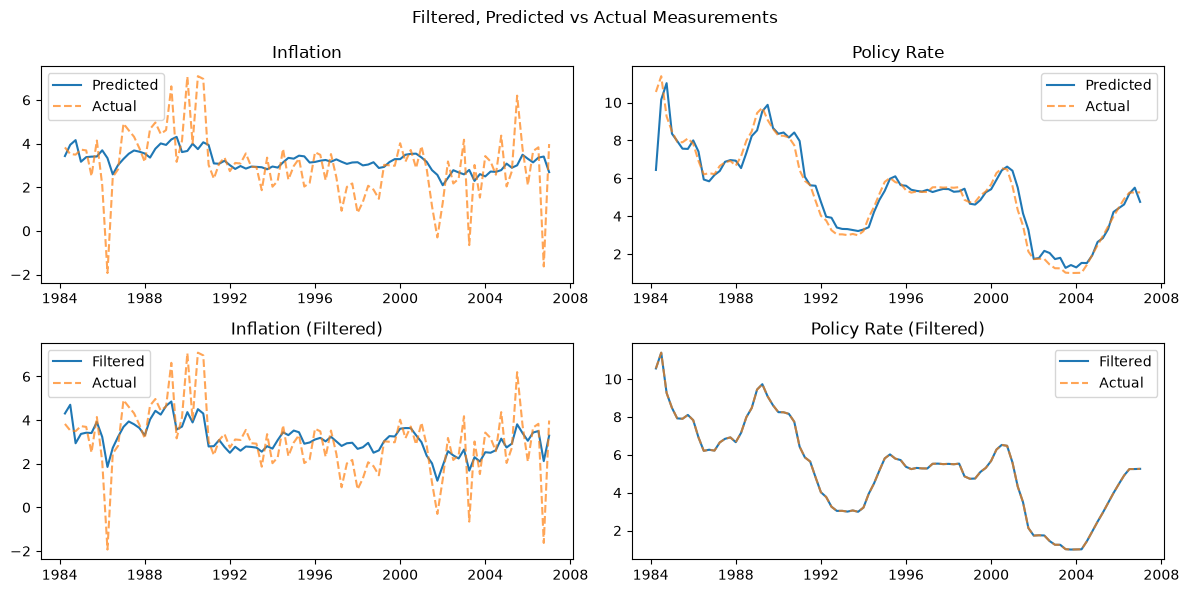

In [13]:
obs = observed.loc[observed.index >= "1984-01-01", :]
idx = obs.index

fig, ax = plt.subplots(2, 2, figsize=(12, 6))
ax = ax.flatten()

plt.suptitle("Filtered, Predicted vs Actual Measurements")

ax[0].plot(idx, kf_0.y_pred[:, 0], label="Predicted")
ax[0].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[0].set_title("Inflation")
ax[0].legend()

ax[1].plot(idx, kf_0.y_pred[:, 1], label="Predicted")
ax[1].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[1].set_title("Policy Rate")
ax[1].legend()

ax[2].plot(idx, kf_0.y_filt[:, 0], label="Filtered")
ax[2].plot(idx, obs.iloc[:, 0], label="Actual", linestyle="--", alpha=0.7)
ax[2].set_title("Inflation (Filtered)")
ax[2].legend()

ax[3].plot(idx, kf_0.y_filt[:, 1], label="Filtered")
ax[3].plot(idx, obs.iloc[:, 1], label="Actual", linestyle="--", alpha=0.7)
ax[3].set_title("Policy Rate (Filtered)")
ax[3].legend()

plt.tight_layout()